# Final Machine Learning Pipeline

The pipeline features

- open source classes
- in house package classes
- only uses the selected features
- we score new data

# Reproducibility: Setting the seed

With the aim to ensure reproducibility between runs of the same notebook, but also between the research and production environment, for each step that includes some element of randomness, it is extremely important that we **set the seed**.

In [1]:
import sys

## importar el script preprocessors
sys.path.append('../src/preprocessors.py')

In [2]:
# data manipulation and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# for saving the pipeline
import joblib

# from Scikit-learn
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, Binarizer

# from feature-engine
from feature_engine.imputation import (
    AddMissingIndicator,
    MeanMedianImputer,
    CategoricalImputer,
)

from feature_engine.encoding import (
    RareLabelEncoder,
    OrdinalEncoder,
)

from feature_engine.transformation import LogTransformer

from feature_engine.selection import DropFeatures
from feature_engine.wrappers import SklearnTransformerWrapper

import preprocessors as pp

In [3]:
# load dataset
data = pd.read_csv('../data/raw/train.csv')

# rows and columns of the data
print(data.shape)

# visualise the dataset
data.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Cast MSSubClass as string
data['MSSubClass'] = data['MSSubClass'].astype(str)

# Separar el conjunto de datos en entrenamiento y prueba

Es importante separar nuestros datos en un conjunto de entrenamiento y un conjunto de prueba.

Cuando diseñamos características, algunas técnicas aprenden parámetros a partir de los datos. Es fundamental que estos parámetros se aprendan solo del conjunto de entrenamiento para evitar el over-fitting.

Nuestras técnicas de ingeniería de características aprenderán:

- mean
- mode
- exponents for the yeo-johnson
- category frequency
- and category to number mappings

a partir del conjunto de entrenamiento.

**Separar los datos en entrenamiento y prueba implica aleatoriedad, por lo que es necesario fijar la semilla.**

In [5]:
# Separémoslo en conjuntos de entrenamiento y prueba
# Recuerda fijar la semilla (random_state para esta función de sklearn)

X_train, X_test, y_train, y_test = train_test_split(
    data.drop(['Id', 'SalePrice'], axis=1), # predictive variables
    data['SalePrice'], # target
    test_size=0.1, # portion of dataset to allocate to test set
    random_state=0, # we are setting the seed here
)

X_train.shape, X_test.shape

((1314, 79), (146, 79))

# Target

Aplicamos el logaritmo

In [6]:
y_train = np.log(y_train)
y_test = np.log(y_test)

# Configuration

In [7]:
# categorical variables with NA in train set
CATEGORICAL_VARS_WITH_NA_FREQUENT = ['BsmtQual', 'BsmtExposure',
                                     'BsmtFinType1', 'GarageFinish']


CATEGORICAL_VARS_WITH_NA_MISSING = ['FireplaceQu']


# numerical variables with NA in train set
NUMERICAL_VARS_WITH_NA = ['LotFrontage']


TEMPORAL_VARS = ['YearRemodAdd']
REF_VAR = "YrSold"

# this variable is to calculate the temporal variable,
# can be dropped afterwards
DROP_FEATURES = ["YrSold"]

# variables to log transform
NUMERICALS_LOG_VARS = ["LotFrontage", "1stFlrSF", "GrLivArea"]


# variables to binarize
BINARIZE_VARS = ['ScreenPorch']

# variables to map
QUAL_VARS = ['ExterQual', 'BsmtQual',
             'HeatingQC', 'KitchenQual', 'FireplaceQu']

EXPOSURE_VARS = ['BsmtExposure']

FINISH_VARS = ['BsmtFinType1']

GARAGE_VARS = ['GarageFinish']

FENCE_VARS = ['Fence']


# categorical variables to encode
CATEGORICAL_VARS = ['MSSubClass',  'MSZoning',  'LotShape',  'LandContour',
                    'LotConfig', 'Neighborhood', 'RoofStyle', 'Exterior1st',
                    'Foundation', 'CentralAir', 'Functional', 'PavedDrive',
                    'SaleCondition']


# variable mappings
QUAL_MAPPINGS = {'Po': 1, 'Fa': 2, 'TA': 3,
                 'Gd': 4, 'Ex': 5, 'Missing': 0, 'NA': 0}

EXPOSURE_MAPPINGS = {'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}

FINISH_MAPPINGS = {'Missing': 0, 'NA': 0, 'Unf': 1,
                   'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}

GARAGE_MAPPINGS = {'Missing': 0, 'NA': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}


# the selected variables
FEATURES = [
    'MSSubClass',
    'MSZoning',
    'LotFrontage',
    'LotShape',
    'LandContour',
    'LotConfig',
    'Neighborhood',
    'OverallQual',
    'OverallCond',
    'YearRemodAdd',
    'RoofStyle',
    'Exterior1st',
    'ExterQual',
    'Foundation',
    'BsmtQual',
    'BsmtExposure',
    'BsmtFinType1',
    'HeatingQC',
    'CentralAir',
    '1stFlrSF',
    '2ndFlrSF',
    'GrLivArea',
    'BsmtFullBath',
    'HalfBath',
    'KitchenQual',
    'TotRmsAbvGrd',
    'Functional',
    'Fireplaces',
    'FireplaceQu',
    'GarageFinish',
    'GarageCars',
    'GarageArea',
    'PavedDrive',
    'WoodDeckSF',
    'ScreenPorch',
    'SaleCondition',
    # this one is only to calculate temporal variable:
    "YrSold",
]

In [8]:
X_train = X_train[FEATURES]
X_test = X_test[FEATURES]

X_train.shape, X_test.shape

((1314, 37), (146, 37))

# Pipeline - End-to-end

Tenemos 3 pasos menos, que están comentados. Por lo tanto, el pipeline también es más simple:

- La transformación Yeo-Johnson
- 1 of the mappings
- El procedimiento de selección

Esto hace que el pipeline sea más rápido y fácil de implementar.

In [9]:
X_train[CATEGORICAL_VARS] = X_train[CATEGORICAL_VARS].astype(str)
X_test[CATEGORICAL_VARS] = X_test[CATEGORICAL_VARS].astype(str)

In [10]:
# set up the pipeline
price_pipe = Pipeline([

    # ===== IMPUTATION =====
    ('missing_imputation', CategoricalImputer(
        imputation_method='missing', variables=CATEGORICAL_VARS_WITH_NA_MISSING)),

    ('frequent_imputation', CategoricalImputer(
        imputation_method='frequent', variables=CATEGORICAL_VARS_WITH_NA_FREQUENT)),

    ('missing_indicator', AddMissingIndicator(variables=NUMERICAL_VARS_WITH_NA)),

    ('mean_imputation', MeanMedianImputer(
        imputation_method='mean', variables=NUMERICAL_VARS_WITH_NA
    )),

    # == TEMPORAL VARIABLES ====
    ('elapsed_time', pp.TemporalVariableTransformer(
        variables=TEMPORAL_VARS, reference_variable=REF_VAR)),

    ('drop_features', DropFeatures(features_to_drop=[REF_VAR])),

    # ==== VARIABLE TRANSFORMATION =====
    ('log', LogTransformer(variables=NUMERICALS_LOG_VARS)),

    ('binarizer', SklearnTransformerWrapper(
        transformer=Binarizer(threshold=0), variables=BINARIZE_VARS)),

    # === mappers ===
    ('mapper_qual', pp.Mapper(
        variables=QUAL_VARS, mappings=QUAL_MAPPINGS)),

    ('mapper_exposure', pp.Mapper(
        variables=EXPOSURE_VARS, mappings=EXPOSURE_MAPPINGS)),

    ('mapper_finish', pp.Mapper(
        variables=FINISH_VARS, mappings=FINISH_MAPPINGS)),

    ('mapper_garage', pp.Mapper(
        variables=GARAGE_VARS, mappings=GARAGE_MAPPINGS)),

    # == CATEGORICAL ENCODING
    ('rare_label_encoder', RareLabelEncoder(
        tol=0.01, n_categories=1, variables=CATEGORICAL_VARS
    )),

    ('categorical_encoder', OrdinalEncoder(
        encoding_method='ordered', variables=CATEGORICAL_VARS)),

    #Escalador
    ('scaler', MinMaxScaler()),

    # Agregar el modelo Lasso (Yo escogi)
    ('Lasso', Lasso(alpha=0.001, random_state=0)),
])

In [11]:
!conda update pandas
!pip install --upgrade pandas


PackageNotInstalledError: Package is not installed in prefix.
  prefix: /opt/anaconda3/envs/MLOps-Proyecto-Regresion-Casas
  package name: pandas




In [12]:
# train the pipeline
price_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('missing_imputation', ...), ('frequent_imputation', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,imputation_method,'missing'
,fill_value,'Missing'
,variables,['FireplaceQu']
,return_object,False
,ignore_format,False
,imputation_method,'frequent'
,fill_value,'Missing'


In [13]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
import numpy as np

# make predictions for train set
pred = price_pipe.predict(X_train)

# --- Métricas para el conjunto de entrenamiento ---
# Para MSE, usa mean_squared_error
print('train mse: {}'.format(int(
    mean_squared_error(np.exp(y_train), np.exp(pred)))))

# Para RMSE, usa la nueva función root_mean_squared_error
print('train rmse: {}'.format(int(
    root_mean_squared_error(np.exp(y_train), np.exp(pred)))))

# R2
print('train r2: {}'.format(
    r2_score(np.exp(y_train), np.exp(pred))))
print()

# --- Métricas para el conjunto de prueba ---
pred = price_pipe.predict(X_test)

# Para MSE
print('test mse: {}'.format(int(
    mean_squared_error(np.exp(y_test), np.exp(pred)))))

# Para RMSE
print('test rmse: {}'.format(int(
    root_mean_squared_error(np.exp(y_test), np.exp(pred)))))

# R2
print('test r2: {}'.format(
    r2_score(np.exp(y_test), np.exp(pred))))
print()

print('Average house price: ', int(np.exp(y_train).median()))

train mse: 781396630
train rmse: 27953
train r2: 0.8748530315439075

test mse: 1060769014
test rmse: 32569
test r2: 0.845641557120844

Average house price:  163000


Identical results to when we did all the engineering manually.

Text(0.5, 1.0, 'Evaluation of Lasso Predictions')

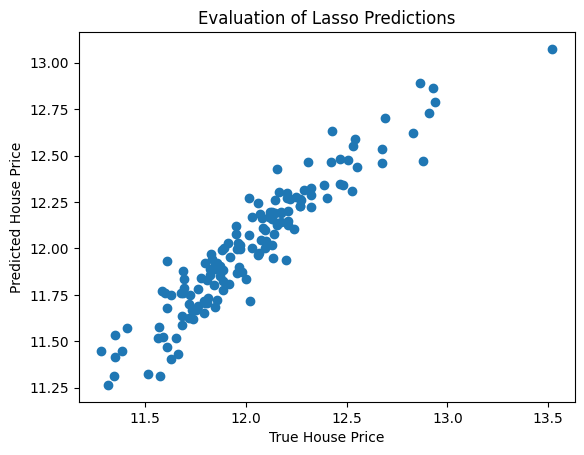

In [14]:
# let's evaluate our predictions respect to the real sale price
plt.scatter(y_test, price_pipe.predict(X_test))
plt.xlabel('True House Price')
plt.ylabel('Predicted House Price')
plt.title('Evaluation of Lasso Predictions')

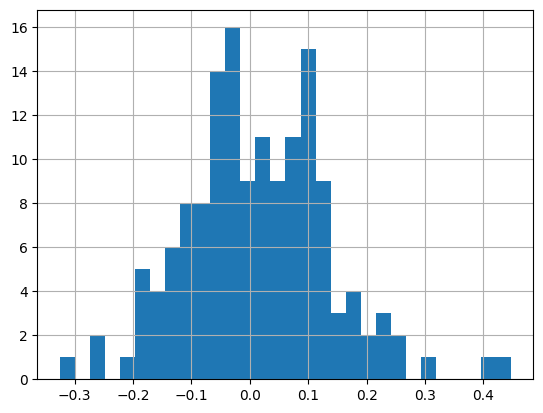

In [15]:
# let's evaluate the distribution of the errors:
# they should be fairly normally distributed

y_test.reset_index(drop=True, inplace=True)

preds = pd.Series(price_pipe.predict(X_test))

errors = y_test - preds
errors.hist(bins=30)
plt.show()

## Guardamos el Pipeline

In [16]:
# Ahora guardamos el pipeline

joblib.dump(price_pipe, '../models/precio_casas_pipeline.joblib')

['../models/precio_casas_pipeline.joblib']

# Score con datos nunca antes vistos (TEST.CSV)

In [17]:
# load the unseen / new dataset
data = pd.read_csv('../data/raw/test.csv')

data.drop('Id', axis=1, inplace=True)

data['MSSubClass'] = data['MSSubClass'].astype(str)

data = data[FEATURES]

print(data.shape)

FileNotFoundError: [Errno 2] No such file or directory: './input/test.csv'

In [ ]:
new_vars_with_na = [
    var for var in FEATURES
    if var not in CATEGORICAL_VARS_WITH_NA_FREQUENT +
    CATEGORICAL_VARS_WITH_NA_MISSING +
    NUMERICAL_VARS_WITH_NA
    and data[var].isnull().sum() > 0]

new_vars_with_na

['MSZoning',
 'Exterior1st',
 'BsmtFullBath',
 'KitchenQual',
 'Functional',
 'GarageCars',
 'GarageArea']

In [ ]:
data[new_vars_with_na].head()

,MSZoning,Exterior1st,BsmtFullBath,KitchenQual,Functional,GarageCars,GarageArea
0,RH,VinylSd,0.0,TA,Typ,1.0,730.0
1,RL,Wd Sdng,0.0,Gd,Typ,1.0,312.0
2,RL,VinylSd,0.0,TA,Typ,2.0,482.0
3,RL,VinylSd,0.0,Gd,Typ,2.0,470.0
4,RL,HdBoard,0.0,Gd,Typ,2.0,506.0


In [ ]:
data[new_vars_with_na].isnull().mean()

MSZoning        0.002742
Exterior1st     0.000685
BsmtFullBath    0.001371
KitchenQual     0.000685
Functional      0.001371
GarageCars      0.000685
GarageArea      0.000685
dtype: float64

In [ ]:
data.dropna(subset=new_vars_with_na, inplace=True)

print(data.shape)

(1449, 37)


In [ ]:
new_preds = price_pipe.predict(data)

/opt/anaconda3/envs/mlops-proyecto-de-regresion/lib/python3.10/site-packages/feature_engine/encoding/rare_label.py:264: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Rare' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X.loc[~X[feature].isin(self.encoder_dict_[feature] + with_nan), feature] = (


In [ ]:
new_preds

array([11.63887553, 11.95044612, 12.07895773, ..., 11.95140323,
       11.69483397, 12.25440613])

<Axes: >

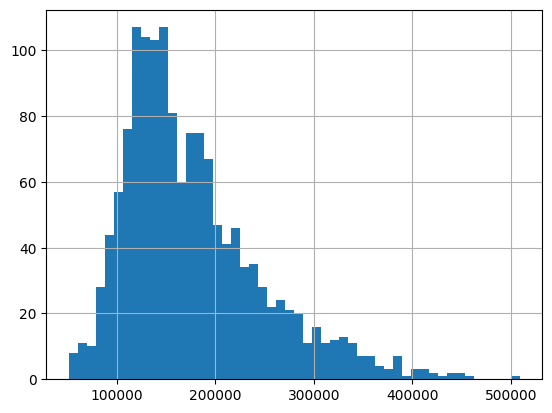

In [ ]:
# let's plot the predicted sale prices
pd.Series(np.exp(new_preds)).hist(bins=50)